In [ ]:
pip install pennylane

  Obtaining dependency information for pennylane from https://files.pythonhosted.org/packages/ae/15/325be913d79301f9add4699156d640c3b001351658b836bd7868a0f6cf1f/PennyLane-0.37.0-py3-none-any.whl.metadata
  Obtaining dependency information for rustworkx from https://files.pythonhosted.org/packages/9c/c6/50f5736f5dac1709c6c8b6ac3470f466fd793dd25c081923942caf13051f/rustworkx-0.15.1-cp38-abi3-win_amd64.whl.metadata
  Obtaining dependency information for autograd from https://files.pythonhosted.org/packages/81/70/d5c7c2a458b8be96495c8b1634c2155beab58cbe864b7a9a5c06c2e52520/autograd-1.6.2-py3-none-any.whl.metadata
  Obtaining dependency information for semantic-version>=2.7 from https://files.pythonhosted.org/packages/6a/23/8146aad7d88f4fcb3a6218f41a60f6c2d4e3a72de72da1825dc7c8f7877c/semantic_version-2.10.0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for autoray>=0.6.11 from https://files.pythonhosted.org/packages/1c/49/69aaa6e5a946b1965b7a42fc515449ae5a2bb7cd7e8a4df8b71

In [ ]:
pip install yfinance

  Obtaining dependency information for yfinance from https://files.pythonhosted.org/packages/db/fc/10b7d339ccf6725e13408d76fb1e944f512590a949af426503c38d4af712/yfinance-0.2.41-py2.py3-none-any.whl.metadata
  Obtaining dependency information for multitasking>=0.0.7 from https://files.pythonhosted.org/packages/3e/8a/bb3160e76e844db9e69a413f055818969c8acade64e1a9ac5ce9dfdcf6c1/multitasking-0.0.11-py3-none-any.whl.metadata
  Obtaining dependency information for frozendict>=2.3.4 from https://files.pythonhosted.org/packages/6a/71/3656c00606e75e81f11721e6a1c973c3e03da8c7d8b665d20f78245384c6/frozendict-2.4.4-py311-none-any.whl.metadata
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
      --------------------------------------- 0.0/3.0 MB 991.0 kB/s eta 0:00:03
     - -------------------------------------- 0.1/3.0 MB 651.6 kB/s eta 0:00:05
     - -------------------------------------- 0.1/3.0 MB 726.

In [ ]:
import pandas as pd
import yfinance as yf

assets = "MSFT BRK-B ASML LLY"
StockStartDate = '2023-01-01'
StockEndDate = '2023-12-31'
interval = '1d'

df = yf.download(assets, start=StockStartDate,\
                 end=StockEndDate, interval=interval)['Adj Close']

# daily return distribution
ret = df.pct_change().dropna()

# mean return vector & covariance matrix (annualized)
R = ret.mean()*252
Sigma = ret.cov()*252

[*********************100%%**********************]  4 of 4 completed


![image.png](attachment:image.png)

In [ ]:
import pennylane as qml
from pennylane import numpy as np

# define parameters in H
N = 4     # number of total assets
gamma = 1  # risk aversion coefficient
B = 2      # budget
P = 1.0    # penalty

ZZ = [qml.PauliZ(i)@qml.PauliZ(j) for i in range(N) for j in range(i+1,N)]
ZZ_coeff = [0.5*(gamma*Sigma.values[i][j] + P) for i in range(N) for j in range(i+1,N)]
Z = [qml.PauliZ(i) for i in range(N)]
Z_coeff = [-0.5*gamma*(sum(Sigma.values[i][:])) + 0.5*R[i] - 0.5*P*(N-2*B) for i in range(N)]
C = 0.25*gamma*(sum(sum(Sigma.values)) + np.trace(Sigma))- 0.5*sum(R) + 0.25*P*(N + (N-2*B)**2)

# Construct the problen Hamiltonian
obs = ZZ + Z
coeffs = ZZ_coeff + Z_coeff
H = qml.Hamiltonian(coeffs, obs, grouping_type="qwc")

In [ ]:
# Design the ansatz
p = 2     # circuit repetitions
def ansatz(params, qubits, depth=p):
    for q in range(qubits):
            qml.RY(params[q], wires=q)
    for d in range(1,depth+1):
        for q in range(qubits-1):
            qml.CNOT(wires=[q,q+1])
        for q in range(qubits):
            qml.RY(params[d*qubits+q], wires=q)

In [ ]:
dev = qml.device("default.qubit", wires=N)

# Set the cost function on dev
@qml.qnode(dev, diff_method="parameter-shift")
def cost(x):
    ansatz(x, qubits=N)
    return qml.expval(H)

# For analyze the optimized circuit
@qml.qnode(dev)
def probability_circuit(params):
    ansatz(params, qubits=N)
    return qml.probs(wires=range(N))

In [ ]:
opt = qml.QNGOptimizer(stepsize=0.02)
max_steps=2000
init_params = np.random.rand((p+1)*N)

params = init_params
old_cost = 9999.999999
for i in range(max_steps):
    params = opt.step(cost, params)
    obj_value = cost(params)
    if (i + 1) % 5 == 0:
        print("Cost after step {:5d}: {: .7f}".format(i + 1, obj_value))
        if np.round(old_cost, 7) == np.round(obj_value, 7):
            break
        else:
            old_cost = obj_value

print("Optimized parameters: {}".format(params))
print("Optimized objective function value: {}".format(obj_value))

Cost after step     5: -0.3330343
Cost after step    10: -0.4924782
Cost after step    15: -0.5710731
Cost after step    20: -0.6629441
Cost after step    25: -0.7736063
Cost after step    30: -0.8961331
Cost after step    35: -1.0132442
Cost after step    40: -1.1054734
Cost after step    45: -1.1645242
Cost after step    50: -1.1964369
Cost after step    55: -1.2121164
Cost after step    60: -1.2196982
Cost after step    65: -1.2235759
Cost after step    70: -1.2258078
Cost after step    75: -1.2273041
Cost after step    80: -1.2284589
Cost after step    85: -1.2294426
Cost after step    90: -1.2303297
Cost after step    95: -1.2311532
Cost after step   100: -1.2319282
Cost after step   105: -1.2326622
Cost after step   110: -1.2333592
Cost after step   115: -1.2340218
Cost after step   120: -1.2346519
Cost after step   125: -1.2352509
Cost after step   130: -1.2358203
Cost after step   135: -1.2363614
Cost after step   140: -1.2368754
Cost after step   145: -1.2373635
Cost after ste

Final solution : 0011, with prob=0.99999


C:\Users\kevin\AppData\Local\Temp\ipykernel_6480\3636598091.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


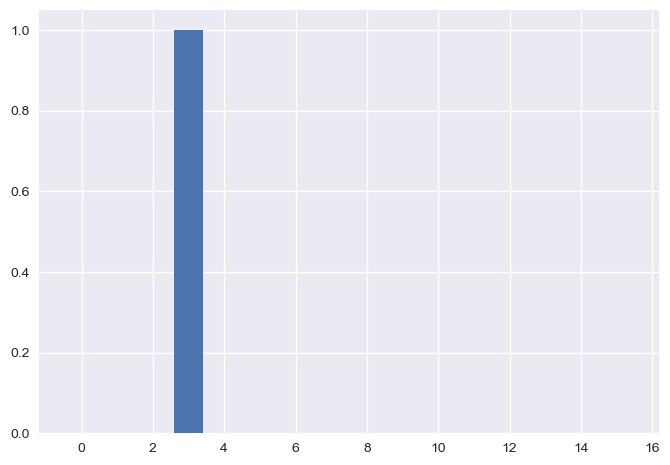

In [ ]:
import matplotlib.pyplot as plt

probs = probability_circuit(params)
print("Final solution : {:04b}, with prob={:.5f}".format(np.argmax(probs), max(probs)))
plt.style.use("seaborn")
plt.bar(range(2 ** len(range(N))), probs)
plt.show()

In [ ]:
import itertools
all_combinations = itertools.product([0, 1], repeat=N)

E_g = 99999.99999
for x in all_combinations:
    E = gamma*np.dot(x, np.dot(Sigma, x)) - np.dot(R,x) + P*(sum(x)-B)**2
    if E < E_g:
        E_g = E
        sol = x
print("Exact solution:{}".format(sol))

Exact solution:(0, 0, 1, 1)


Dari hasil di atas, disimpulkan bahwa potofolio yang direkomendasi berdasarkan data dari tanggal 1 Januari 2023 sampai 31 Desember 2023 yaitu ASML dan LLY dengan hasil data 3 bulan setelah range waktu tersebut (sebagai hasil prediksi) yaitu sebagai berikut.

![image.png](attachment:image.png)

Jika di-*compare* dengan S&P 500 ETF (SPY), didapat seperti pada gambar berikut.

![image.png](attachment:image.png)